# <a id='toc1_'></a>[Bericht zur Datenqualität (epi2025_1)](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Bericht zur Datenqualität (epi2025_1)](#toc1_)    
  - [Änderungen seit der letzten Version](#toc1_1_)    
  - [Hinweise](#toc1_2_)    
  - [Datenstand](#toc1_3_)    
  - [Fallzahlen im Verlauf der Jahreslieferungen](#toc1_4_)    
    - [original geliefert vor ZfKD Prüfungen](#toc1_4_1_)    
    - [jeweils letztes DJ nach ZfKD  Prüfungen](#toc1_4_2_)    
  - [Variablenverteilung](#toc1_5_)    
    - [Diagnosejahr](#toc1_5_1_)    
    - [Diagnosegruppen](#toc1_5_2_)    
    - [Diagnosesicherung](#toc1_5_3_)    
    - [DCO Diagramm](#toc1_5_4_)    
    - [DCO](#toc1_5_5_)    
    - [Angabe Register vs Bundesland](#toc1_5_6_)    
  - [Histologien](#toc1_6_)    
    - [Dignität](#toc1_6_1_)    
    - [Grading](#toc1_6_2_)    
    - [Altersgruppen Kinder und Heranwachsende](#toc1_6_3_)    
    - [UICC](#toc1_6_4_)    
    - [TNM-Auflage](#toc1_6_5_)    
    - [Tod](#toc1_6_6_)    
      - [Anteil Verstorbene](#toc1_6_6_1_)    
      - [Verteilung Todesursachen nach ICDT10](#toc1_6_6_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

<br>

## <a id='toc1_1_'></a>[Änderungen seit der letzten Version](#toc0_)
<!-- - bisher wurden folgende Angaben in einer umfangreichen Verarbeitung im workflow umkodiert: `ICDGM10`, `HISC`, `ICDO3`, `DIG`. Diese Umformung wurde deaktiviert, es finden nun nur noch punktuelle Korrekturen statt -->
- Lieferung Daten mit **Diagnosejahr 2024**

<br>

## <a id='toc1_2_'></a>[Hinweise](#toc0_)
- Neben den Hinweisen zum Verständnis der Auswertungen sind auch häufig **Interpretationen** angefügt, diese sind optisch abgesetzt als **Notiz** erkennbar
- die jeweils angewendeten **Filter** sind für jede Auswertung dargestellt, jeweils zur besseren Einordnung als Anteil von der Gesamtzahl der Entität in unserer Datenbank
- die _relativen_ Barcharts enthalten ein `Total` item für den Gesamtvergleich
- die Filter können exakt nachvollzogen werden mit Hilfe der **ausklappbaren SQL Abfragen**
- in den Diagrammen gibt ebenfalls das angegebene _`n=`_ einen Hinweis auf die verwendete Grundgesamtheit
- der komplette Quellcode dieses Dokumentes ist [hier abrufbar](../../epi.ipynb)

<br>

## <a id='toc1_3_'></a>[Datenstand](#toc0_)

In [1]:
import os
from pathlib import Path
import pandas as pd
import datetime as dt
from pandas_plots import tbl, pls, hlp, const
import duckdb as ddb

from connection_helper import sql
import numpy as np

os.environ["DY_MAX"] = "2024"  # set before import
from mod.filters import *

# hlp.show_package_version()

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

# file_epi = dir_db/'2025-11-06_data_epi.duckdb'
# file_epi = dir_db/'2026-03-03_data_epi.duckdb'
file_epi = dir_db/'2026-05-13_data_epi.duckdb'

if not file_epi.exists():
    raise Exception(f"files {file_epi} not found")

URL_V2 = 'https://gitlab.opencode.de/robert-koch-institut/zentrum-fuer-krebsregisterdaten/cancerdata-references/-/raw/main/data/v2/'

hlp.setup_rendering(
    static=True,
    # apply_dark_theme=True,
    # to_pdf=False,
)

In [2]:
sql.print_meta(file_epi)

database file:           2026-05-13_data_epi.duckdb
data tag:                epi2025_1
sql table created:       2026-05-13 09:31:01
doi:                     10.18444/5.03.01.0005.0022.0001
document created:        2026-05-20 18:14:59


In [3]:
FILTERS_DY_RANGE = ("z_dy between 2019 and 2025", "DJ 2019-2025")
FILTERS_DY_FROM_2010 = ("z_dy >= 2010", "DJ ab 2010")

In [4]:
_=con = ddb.connect(file_epi, read_only=True)
_=con.execute("PRAGMA disable_progress_bar;")

In [5]:
# dim_dig = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/dig.csv", sep=";")
# dim_dsich_epi = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/diagnosesicherung_epi.csv", sep=";")
# dim_grading_epi = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/grading_epi.csv", sep=";")
# dim_icd10_3d = sql.load_file_to_duckdb(con, URL_V2 + "Aggregationen/icd10_3d.csv", sep=";")
dim_lieferregister_epi = con.table("dim_lieferregister_epi").to_df()
dim_lieferregister_clin = con.table("dim_lieferregister_clin").to_df()

In [6]:
Batches = con.table("_batches")
Checks = con.table("_checks")
ColumnCheck = con.table("_columncheck")
Frequencies = con.table("_frequencies")
# _meta_meta = con.sql("select * from meta._meta;")

df_checks = Checks.to_df().astype({"EKRNR": str})
df_freqs = (
    Frequencies.project(
        "*, concat(cast(BatchID as varchar),' | ', cast(cast(BatchZeit as date) as varchar)) as batch_label"
    )
    .to_df()
    .astype({"EKRNR": str})
)
df_freqs["EKRNR"] = df_freqs["EKRNR"].astype(int).replace(dim_lieferregister_epi["kkr"].to_dict())
df_checks["EKRNR"] = df_checks["EKRNR"].astype(int).replace(dim_lieferregister_epi["kkr"].to_dict())
df_batches= Batches.to_df()
df_columnchecks= ColumnCheck.to_df().set_index('ColumnCheckID')
df_checks = df_checks.join(df_columnchecks, on='ColumnCheckID')
df_checks["check_label"] = df_checks.apply(lambda x: f"{x['Alias']}[{x['ColumnCheckID']}]", axis=1)
df_checks= df_checks[["EKRNR","Anzahl","BatchID","DJahr","check_label","ColumnCheckID"]]

In [7]:
db_freqs = con.sql("""--sql
    select f.Alias, f.EKRNR, f.Wert, f.DJahr, f.Anzahl, f.Stufe, f.BatchID, Anzahl,
    BatchID::text || ' | ' || BatchZeit::varchar as batch_label,
    l.kkr,
    from _frequencies f
    join dim_lieferregister_epi l on f.EKRNR = l.code
""")
# db_freqs.show()

In [8]:
# db_epi = con.sql("select * from tumor_epi_clin_all;")

In [9]:
batch_max=df_checks['BatchID'].max()
batch_list = [batch_max,418,399,360]
batch_min=399
db_list_dy="(2024)"    # must be a str list, since "alt" is in dy col - or a ddb compatible str

In [10]:
print(f"\n{'aktuellster batch': <32}{batch_max}")
print(f"{'aktuellstes Diagnosejahr 📆': <30} {db_list_dy}")


aktuellster batch               426
aktuellstes Diagnosejahr 📆     (2024)


<div style="page-break-after: always;"></div>

## <a id='toc1_4_'></a>[Fallzahlen im Verlauf der Jahreslieferungen](#toc0_)
- kein Filter
- es werden Datenstände (_batch_) aus mehreren Lieferjahren dargestellt , welche über eine laufende Nummer sowie das Datum der Ausführung vergleichbar sind
- in Abgrenzung zu den klinischen Daten ist jede einzelne EKR Lieferung für das gesamte Lieferjahr gültig
- dargestellt sind die **letzten 5 veröffentlichten** Datenstände 

<br>

### <a id='toc1_4_1_'></a>[original geliefert vor ZfKD Prüfungen](#toc0_)
- die Übersicht macht erkennbar, wie sich die Fallzahlen absolut und relativ im Laufe der letzten Lieferungen entwickelt haben
- aufgeführt sind die Fallzahlen aus den überlieferten Dateien **vor** den ZfKD Anpassungen
- `batch_label` markiert den jeweils letzten offiziellen Datenstand des Lieferjahres, sowie den aktuellen Datenstand

In [11]:
_df=df_freqs[(df_freqs.Stufe==2) & (df_freqs.Alias=="SEX") & (df_freqs.BatchID.isin(batch_list))]
_df=_df.pivot_table(index="batch_label", columns="EKRNR", values="Anzahl", aggfunc="sum")
tbl.show_num_df(
    _df,
    total_axis="y",
    data_bar_axis="x",
    font_size_th=12,
    font_size_td=11,
    col1_width=135,
)

EKRNR,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,Total
batch_label,,,,,,,,,,,,
360 | 2023-01-03,624_239,371_807,1_545_623,132_265,2_906_452,782_871,632_930,766_070,1_535_587,360_943,3_605_815,13_264_602
399 | 2024-12-02,734_305,423_109,1_816_413,151_753,3_991_177,918_534,823_343,1_048_203,1_811_372,400_646,3_792_956,15_911_811
418 | 2025-06-20,780_626,445_714,1_911_528,157_932,4_186_192,973_597,863_935,1_152_455,1_916_313,412_559,3_950_260,16_751_111
426 | 2026-05-13,824_131,462_565,2_011_492,162_936,4_546_268,1_022_281,906_983,1_259_176,2_030_094,429_016,4_103_845,17_758_787


<br>

### <a id='toc1_4_2_'></a>[jeweils letztes DJ nach ZfKD  Prüfungen](#toc0_)
- Filter: jeweils das **letzte DJ** der einzelnen Jahreslieferung
- aufgeführt sind die Fallzahlen aus den überlieferten Dateien **nach** den ZfKD Anpassungen
<!-- - eine Aufschlüsselung von `11-GKR` wäre hier sinnhaft, allerdings  -->

In [12]:
# todo  inzidenz-BL
_df=df_freqs[
    (df_freqs.Stufe==5) & 
    (df_freqs.Alias=="SEX") & 
    (df_freqs.BatchID.isin(batch_list))
    & (df_freqs.DJahr!="alt")
    ]
_df=_df.pivot_table(index="batch_label", columns="EKRNR", values="Anzahl", aggfunc="sum")
tbl.show_num_df(
    _df,
    total_axis="y",
    data_bar_axis="x",
    font_size_th=12,
    font_size_td=11,
    col1_width=135,
)

EKRNR,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,Total
batch_label,,,,,,,,,,,,
360 | 2023-01-03,32_401,17_099,81_092,6_548,176_210,38_279,25_194,77_968,85_001,11_391,164_812,715_995
399 | 2024-12-02,33_243,18_238,85_016,6_086,193_412,38_294,28_779,78_883,80_929,11_665,162_633,737_178
418 | 2025-06-20,34_512,18_011,86_331,5_068,202_655,44_073,30_000,81_320,84_717,11_076,155_450,753_213
426 | 2026-05-13,36_307,17_987,87_692,4_687,215_180,42_721,31_878,82_957,86_674,12_247,146_457,764_787


In [13]:
# # todo delta values from counts of historic sql / duckdb databases. this func has only has GKR data

# lol = con.sql("""--sql
#     with base as (
#         select 
#             batchID,
#             batch_label,
#             kkr,
#             sum(Anzahl) as Anzahl,
#         from db_freqs 
#         where Stufe=5 
#         and Alias='SEX'
#         and DJahr <> 'alt'
#         and batchID in (426, 418, 399, 360)
#         group by all
#     )
#     select
#         batch_label,
#         kkr,
#         Anzahl - lag(Anzahl) over (partition by kkr order by batchID) as diff,
#     from base
#     order by batchID, kkr
#     """)
# # lol.show()
# tbl.pivot_df(
#     lol.to_df(),
#     data_bar_axis="",
#     heatmap_axis="xy",
#     pct_axis="",
#     total_axis="y",
#     font_size_th=12,
#     font_size_td=11,
#     # color_highlight_style="bright",
# )

In [14]:
# # * internal check
# _df=(df_checks[(df_checks.ColumnCheckID==48) & (df_checks.BatchID >= batch_min) & (df_checks.BatchID != 415)].sort_values('BatchID'))
# _df=_df.pivot_table(index="BatchID", columns="EKRNR", values="Anzahl", aggfunc="sum").fillna(0)
# tbl.show_num_df(_df, total_axis="y", data_bar_axis="x")

<div style="page-break-after: always;"></div>

## <a id='toc1_5_'></a>[Variablenverteilung](#toc0_)
<!-- - **Filter:**
  - **🚨 sofern nicht anders angegeben ist der Zeitraum beschränkt auf das höchste Diagnosejahr (für `epi2024`: 2023) 🚨**
  - Diagnosen: ausgeschlossen sind `C44` und alle `D` -->
- ab hier wird nur noch die **aktuelle Datenlieferung** dargestellt
- als ungültig markierte Fälle (_A-Prüfungen_) sind in allen Fallzahlen **ausgeschlossen**
- in den barplots sind die relativen Häufigkeiten von Variablen im Datensatz der Register aufgetragen
- zusätzlich ist die Angabe für alle Register enthalten (`Total`)
- näherungsweise sind **GKZ-Bundesländer** verwendet anstatt Lieferregister, um 11-16 aufspannen zu können

<br>

### <a id='toc1_5_1_'></a>[Diagnosejahr](#toc0_)

In [15]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY_RANGE,
    # FILTERS_C,
    FILTERS_NO_DCO,
    FILTERS_NO_C44,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        z_dy,
        GKZbl_label as bl,
    from tumor_epi_clin_all tum
    where {_filter}
    """
).to_df()
# _df
tbl.pivot_df(
    _df,
    data_bar_axis="x",
    pct_axis="",
    total_axis="y",
    font_size_th=12,
    font_size_td=11,
    # color_highlight_style="bright",
)

<!-- START_TOKEN -->

n = 17_758_787                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 17_038_328  (95.9%) ░░████████████████████████████
└ [DJ 2019-2025]:            n = 4_667_333  (26.3%) ░░░░░░░░░░░░░░░░░░░░░░░███████
└ [keine DCO]:               n = 4_446_303  (25.0%) ░░░░░░░░░░░░░░░░░░░░░░░███████
└ [keine C44,D04]:           n = 3_569_966  (20.1%) ░░░░░░░░░░░░░░░░░░░░░░░░██████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy between 2019 and 2025
and not z_is_dco
and z_icd10_3d not in ('C44','D04')
```

</details>

bl,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
z_dy,,,,,,,,,,,,,,,,,
2019,23_023,12_099,57_401,4_820,135_101,37_993,29_858,75_684,80_909,8_234,23_568,19_989,13_007,32_597,16_561,13_925,584_769
2020,23_253,12_750,57_021,4_597,132_121,38_315,29_483,74_029,80_671,7_764,23_752,20_397,13_878,32_150,17_411,14_929,582_521
2021,24_603,13_162,57_971,4_733,130_959,40_166,31_678,76_769,84_241,8_469,24_574,20_721,14_692,33_172,17_455,15_492,598_857
2022,23_513,13_157,58_495,5_024,131_939,40_689,31_420,77_544,86_775,8_478,24_947,20_420,14_380,33_121,17_754,15_609,603_265
2023,23_173,12_781,59_855,4_712,136_358,40_275,31_806,78_317,88_021,8_279,25_687,20_786,14_746,33_334,17_987,15_244,611_361
2024,22_820,12_347,58_415,4_371,136_777,37_958,29_536,74_961,81_866,8_349,24_068,19_314,14_685,32_958,17_293,13_475,589_193


### <a id='toc1_5_2_'></a>[Diagnosegruppen](#toc0_)

> [!NOTE]
> 💡 **ZfKD**: Auffallend ist vor allem der unterschiedlich hohe Anteil von C44 aufgrund unterschiedlicher Landesgesetze: Je nach Bundesland werden nicht-melanotische Hautkrebsformen unterschiedlich gemeldet oder vergütet. Während manche Länder noch alle Hauttumoren erfassen, konzentrieren sich andere bereits auf die &quot;prognostisch ungünstigen&quot; Verläufe, deren Erfassung im Rahmen der klinischen Krebsregistrierung seit 2023 von der GKV finanziert wird

<!-- START_TOKEN -->

n = 17_758_787                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 17_038_328  (95.9%) ░░████████████████████████████
└ [DJ 2024]:                   n = 764_787   (4.3%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy = 2024
```

</details>

<!-- ALT_TEXT:Diagnosegruppen-->

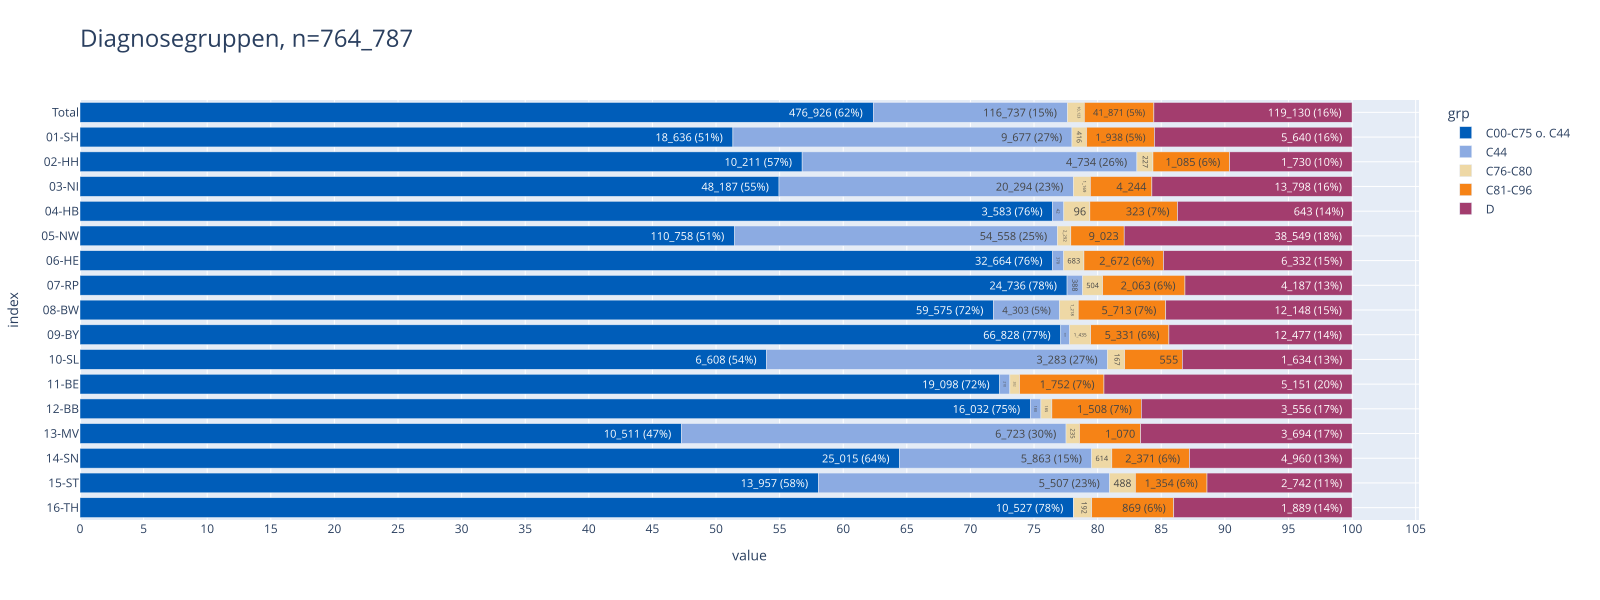

In [16]:
# C00-C75 außer C44
# C44
# C76-C80
# C81-C96
# D
_filters = [
    FILTERS_VALID,
    # FILTERS_DY,
    FILTERS_DY_MAX,
    # FILTERS_NO_DCO,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_pat_id",
    first_n_filter_apply_to_rows=0,
)

_db = con.sql(f"""--sql
    select
        --z_icd10_3d,
        GKZbl_label,
        z_dy,
        case 
            when left(z_icd10_3d,1) = 'D' then 'D'
            when z_icd10_3d = 'C44' then 'C44'
            when right(z_icd10_3d,2)::int8 < 76 then 'C00-C75 o. C44'
            when right(z_icd10_3d,2)::int8 < 81 then 'C76-C80'
            when right(z_icd10_3d,2)::int8 < 97 then 'C81-C96'
        else null end as grp,
        count(*) as cnt
    from tumor_epi_clin_all
    where {_filter}
    group by all
    """)

# _db.filter("True").show()

pls.plot_stacked_bars(
    _db.project("GKZbl_label, grp, cnt").to_df(),
    orientation='h',
    relative=True,
    show_pct_bar=True,
    show_total=True,
    title="Diagnosegruppen"
)

# pls.plot_facet_stacked_bars(
#     _db.project("z_dy, grp, z_kkr_label, cnt").to_df(),
#     relative=True,
#     annotations=True,
#     fill_index=True,
#     title="ICD10 Gruppen"
    
# )

<br>

### <a id='toc1_5_3_'></a>[Diagnosesicherung](#toc0_)

> [!NOTE]
> 💡 **ZfKD**
> - der Großteil der Meldungen basiert auf einer histologischen Sicherung der Diagnose
> - Der Anteil dieser Fälle hat in den ostdeutschen Registern zuletzt zugenommen
> - `08-BW` hat einen hohen Anteil an fehlenden Diagnosesicherungen mit zuletzt stark ansteigendem Trend
> - Der Anteil einer histologischen Sicherung einer Metastase ist insgesamt gering, zeigt aber teilweise deutliche Unterschiede zwischen den Registern (ca. zwischen 0 und 5%)

In [17]:
# _filters = [
#     FILTERS_VALID,
#     FILTERS_DY_MAX,
#     FILTERS_C,
#     FILTERS_NO_C44,
# ]
# _filter = hlp.get_duckdb_filter_n(
#     con=con,
#     query="from tumor_epi_clin_all",
#     filters=_filters,
#     # distinct_metric="z_tum_id",
#     first_n_filter_apply_to_rows=0,
# )

# _df = con.sql(f"""--sql
#     select
#         --z_dy::text as z_dy,
#         GKZbl_label as bl,
#         label as DSICH,
#     from tumor_epi_clin_all tum
#     left join dim_dsich_epi ds on tum.DSICH::text = ds.code
#     where {_filter}
#     """
# ).to_df()
# _df

# _=pls.plot_stacked_bars(
#     _df,
#     orientation="h",
#     normalize=False,
#     relative=True,
#     dropna=False,
#     sort_values_index=False,
#     show_total=True,
#     height=700,
# )

<!-- START_TOKEN -->

n = 17_758_787                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 17_038_328  (95.9%) ░░████████████████████████████
└ [DJ ab 2015]:              n = 7_675_888  (43.2%) ░░░░░░░░░░░░░░░░░░████████████
└ [keine C44,D04]:           n = 6_156_522  (34.7%) ░░░░░░░░░░░░░░░░░░░░██████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and DJ >= 2015
and z_icd10_3d not in ('C44','D04')
```

</details>

<!-- ALT_TEXT:Diagnosesicherung-->

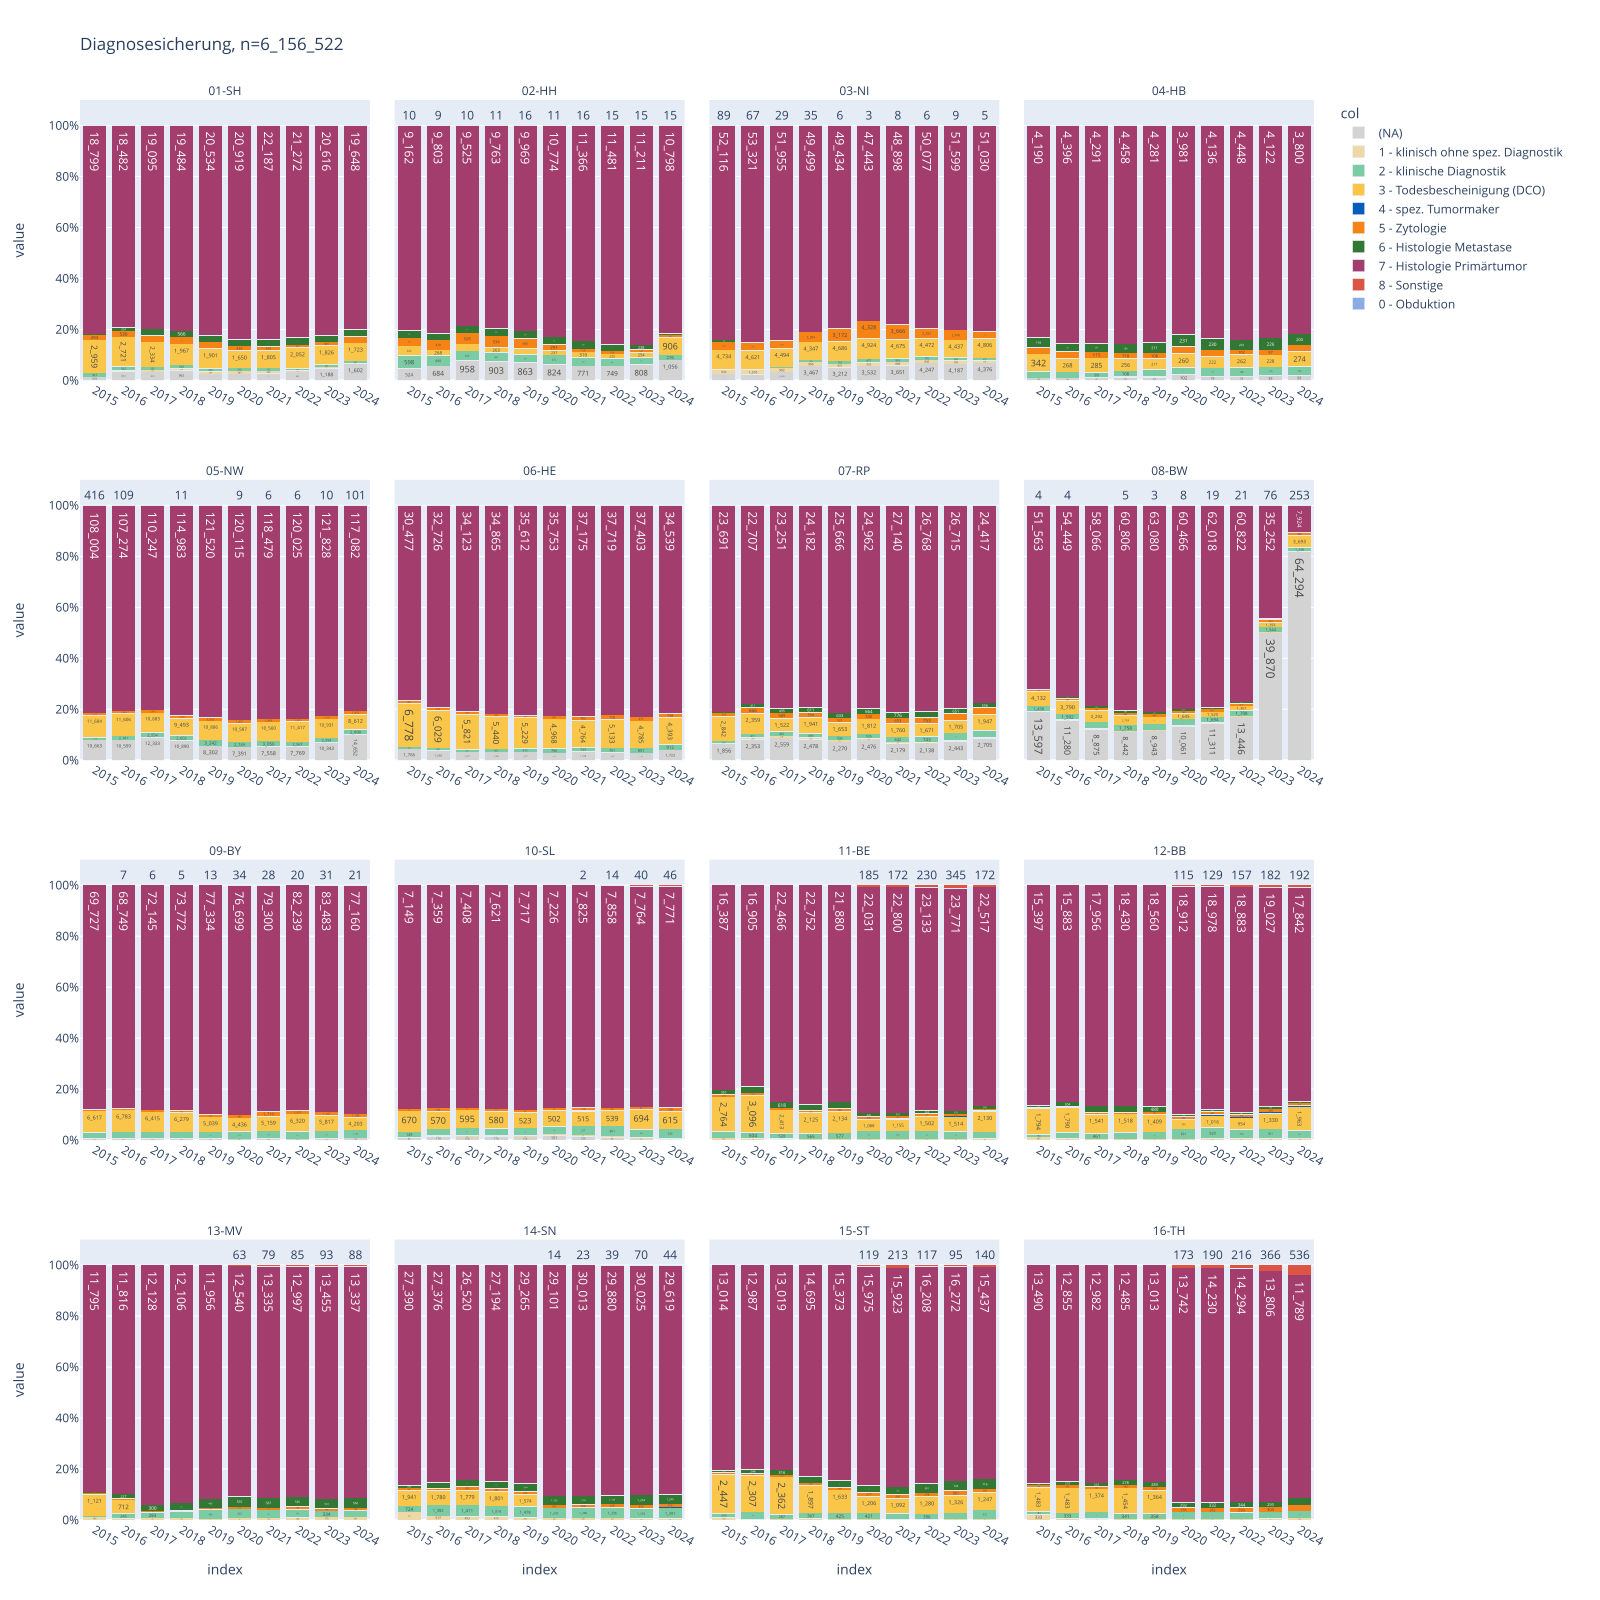

In [18]:
_filters = [
    FILTERS_VALID,
    # ("DJ >= 2010", "DJ ab 2010"),
    ("DJ >= 2015", "DJ ab 2015"),
    # FILTERS_C,
    FILTERS_NO_C44,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        DJ,
        label as DSICH,
        GKZbl_label as bl,
    from tumor_epi_clin_all tum
    left join dim_dsich_epi ds on tum.DSICH::text = ds.code
    where {_filter}
    """
).to_df()
_ = pls.plot_facet_stacked_bars(
    _df,
    relative=True,
    subplot_size=400,
    sort_values_facet=True,
    # sort_values_index=True,
    annotations=True,
    color_palette=const.PALETTE_RKI2,
    title="Diagnosesicherung",
)

<!-- <br>

### <a id='toc1_5_4_'></a>[DCO Diagramm](#toc0_)
- **Filter: DJ = 2020-2024, C44 und D-Diagnosen sind ausgeschlossen, GKZbl 01-16**
- die epi Variable `DCO` wird wie folgt gebildet:
  - 1 wenn Diagnosesicherung = 3
  - sonst 2 (auch für Diagnosesicherung missing)  -->

### <a id='toc1_5_5_'></a>[DCO](#toc0_)
- Metrik: Anteil DCO an Gesamtfallzahl in %

> [!NOTE]
> 💡 **ZfKD**
> - aus 08-BW sind in den ersten 6 Jahren nach Registerstart bewusst keine DCO-Fälle übermittelt worden
> - `13-MV` `14-SN` `16-TH` haben seit Beginn der klinischen Lieferungen aus den LKR fast keine DCO Fälle übermittelt



In [19]:
_filters = [
    FILTERS_VALID,
    FILTERS_C,
    FILTERS_NO_C44,
    FILTERS_DY_FROM_2010,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_dco = con.sql(f"""--sql
    with t_all as (
        select
            GKZbl_label as bl,
            z_is_dco,
            z_dy,
            z_icd10_3d,
            is_deleted,
        from tumor_epi_clin_all
    )
    select  bl, z_dy,
            count(*) as cnt,
            sum(z_is_dco) as sum_dco,
            sum(z_is_dco) / cnt * 100 as pct_dco,
    from    t_all
    where {_filter}
    group by all
    union
    select  'Total' as bl,
            z_dy,
            count(*) as cnt,
            sum(z_is_dco) as sum_dco,
            sum(z_is_dco) / cnt * 100 as pct_dco,
    from    t_all
    where {_filter}
    group by all
    """)
# tbl.descr_db(db_dco, "dco data")

tbl.pivot_df(
    db_dco.project("bl, z_dy, pct_dco").to_df(),
    swap=True,
    precision=2,
    pct_axis="",
    total_axis="",
    font_size_th=12,
    font_size_td=11,
)

<!-- START_TOKEN -->

n = 17_758_787                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 17_038_328  (95.9%) ░░████████████████████████████
└ [ICD10 nur C]:            n = 15_030_686  (84.6%) ░░░░░█████████████████████████
└ [keine C44,D04]:          n = 12_205_943  (68.7%) ░░░░░░░░░░████████████████████
└ [DJ ab 2010]:              n = 7_690_030  (43.3%) ░░░░░░░░░░░░░░░░░░████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
and z_dy >= 2010
```

</details>

bl,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
z_dy,,,,,,,,,,,,,,,,,
2010,14.04,6.84,8.24,3.35,14.01,17.36,12.10,0,10.66,4.20,7.97,5.28,5.37,3.71,11.37,7.38,9.94
2011,14.33,4.84,7.84,4.33,11.95,16.90,15.15,0,9.70,4.11,7.04,5.37,4.59,3.65,12.52,6.87,9.14
2012,14.85,5.20,8.28,4.48,10.84,17.01,14.50,0,9.31,4.84,12.74,5.77,4.44,3.07,12.19,6.11,8.94
2013,13.91,5.01,7.36,6.33,10.80,18.06,16.63,0,8.78,6.55,12.37,5.55,4.66,2.88,12.68,5.96,8.78
2014,13.90,3.66,7.14,11.47,10.13,18.00,15.55,0.10,8.42,9.96,11.23,5.43,4.16,2.64,11.59,6.40,8.54
2015,13.72,4.05,7.10,7.25,9.58,18.06,10.33,6.18,8.48,8.37,14.01,10.25,9.22,6.25,15.00,9.32,9.54
2016,12.61,2.46,6.73,5.83,9.35,15.47,8.60,5.59,8.96,6.78,15.26,9.93,5.72,5.77,14.11,9.87,8.99
2017,10.59,2.98,6.53,6.15,8.21,14.71,5.57,4.77,8.19,7.00,9.90,7.94,0.19,5.78,14.78,9.15,7.88
2018,8.82,2.44,6.05,5.45,7.17,13.65,6.85,3.92,8.01,6.56,8.87,7.78,0.18,5.65,11.03,10.10,7.22


### <a id='toc1_5_6_'></a>[Angabe Register vs Bundesland](#toc0_)
- neue Bundesländer sind nicht aufgeführt, da Daten erst ab 2020 aus Länderregistern vorliegen
- Fälle ausserhalb des Einzugsbereichs werden im ZfKD ausgeschlossen (`A_EKRNR_GKZ_unplausibel`)

> [!NOTE]
> 💡 **ZfKD**
> * generell wird angestrebt, dass die Fallübermittlung ausschließlich innerhalb des Einzugsbereichs stattfindet
> * `05-NW` übermittelt einen relativ hohen Anteil an Fällen aus anderen Bundesländern

In [20]:
_filters = [
    ("z_kkr < 11", "keine NBL"),
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_db = con.sql(f"""--sql
select
    GKZbl_label as bl,
    --lpad(z_gkzbl::text, 2, '0') as z_gkzbl,
    lpad(z_kkr::text, 2, '0') as z_kkr,
    count(*) as cnt,
from tumor_epi_clin_all
where {_filter}
group by all
""")

# _db.show()

tbl.pivot_df(
    _db.to_df(),
    pct_axis="x",
    # font_size_th=12,
    # font_size_td=11,
)

<!-- START_TOKEN -->

n = 17_758_787                (100.0%) ██████████████████████████████
└ [keine NBL]: n = 13_654_942  (76.9%) ░░░░░░░███████████████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_kkr < 11
```

</details>

z_kkr,01,02,03,04,05,06,07,08,09,10,Total
bl,,,,,,,,,,,
(NA),0,0,0,0,10_513 (0.2%),0,0,0,0,0,10_513 (0.1%)
01-SH,824_131 (100.0%),0,0,0,4_102 (0.1%),0,0,0,0,0,828_233 (6.1%)
02-HH,0,462_565 (100.0%),0,0,2_718 (0.1%),0,0,0,0,0,465_283 (3.4%)
03-NI,0,0,2_011_492 (100.0%),0,119_713 (2.6%),0,0,0,0,0,2_131_205 (15.6%)
04-HB,0,0,0,162_936 (100.0%),2_636 (0.1%),0,0,0,0,0,165_572 (1.2%)
05-NW,0,0,0,0,4_188_341 (92.1%),0,0,0,0,0,4_188_341 (30.7%)
06-HE,0,0,0,0,37_288 (0.8%),1_022_281 (100.0%),0,0,0,0,1_059_569 (7.8%)
07-RP,0,0,0,0,77_115 (1.7%),0,906_983 (100.0%),0,0,0,984_098 (7.2%)
08-BW,0,0,0,0,51_144 (1.1%),0,0,1_259_176 (100.0%),0,0,1_310_320 (9.6%)


## <a id='toc1_6_'></a>[Histologien](#toc0_)

<!-- START_TOKEN -->

n = 17_758_787                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 17_038_328  (95.9%) ░░████████████████████████████
└ [DJ ab 2010]:             n = 11_293_487  (63.6%) ░░░░░░░░░░░███████████████████
└ [keine C44,D04]:           n = 8_935_754  (50.3%) ░░░░░░░░░░░░░░░███████████████
└ [keine DCO]:               n = 8_284_161  (46.6%) ░░░░░░░░░░░░░░░░░█████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy >= 2010
and z_icd10_3d not in ('C44','D04')
and not z_is_dco
```

</details>

<!-- ALT_TEXT:Histologie Gruppen-->

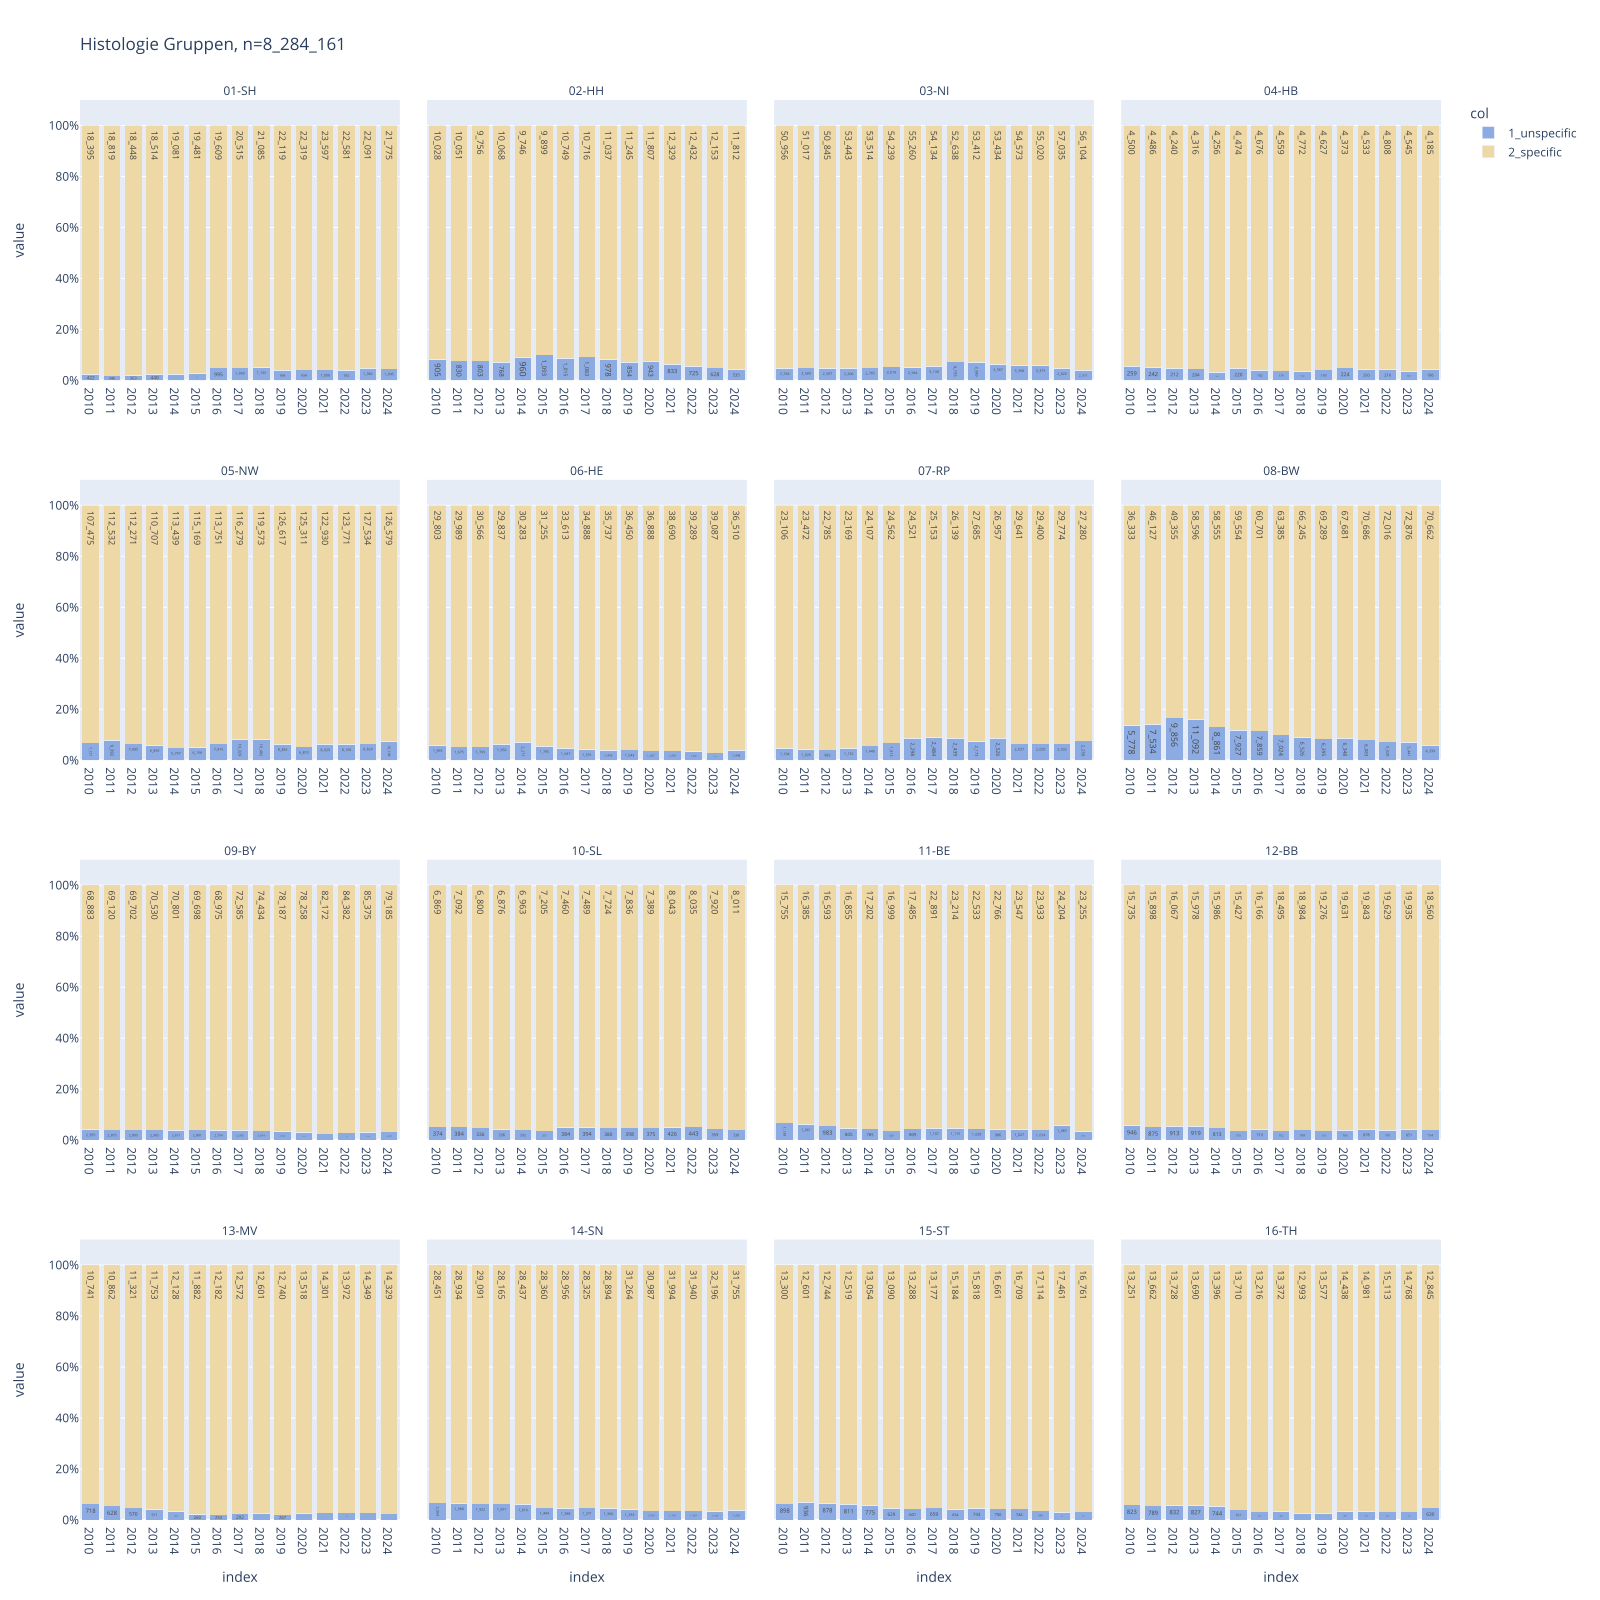

In [31]:
_filters = [
    FILTERS_VALID,
    # FILTERS_DY_MAX,
    # FILTERS_DY,
    FILTERS_DY_FROM_2010,
    FILTERS_NO_C44,
    FILTERS_NO_DCO,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_db = con.sql(f"""--sql
    select
        z_dy::text as z_dy,
        GKZbl_label as bl,
        HISC,
        case
            when
                (HISC::int16 between 8000 and 8011) or
                (HISC::int16 = 9590) or
                (HISC::int16 between 9800 and 9801)
            then '1_unspecific'
            when ifnull(HISC,'') <> '' then '2_specific'
        else null end as hist_grp,
        count(*) as cnt,
    from tumor_epi_clin_all tum
    where {_filter}
    group by all
    """
)
# display(_db.filter("hist_grp = '1_unspecific'"))

# _=pls.plot_stacked_bars(
#     _df[["bl", "Grading", "cnt"]],
#     orientation="h",
#     normalize=False,
#     relative=True,
#     dropna=False,
#     sort_values_index=False,
#     show_total=True,
#     # height=700,
#     show_pct_bar=True,
# )

_ = pls.plot_facet_stacked_bars(
    _db.to_df()[["z_dy", "hist_grp", "bl", "cnt"]],
    relative=True,
    subplot_size=400,
    sort_values_facet=True,
    # sort_values_index=True,
    annotations=True,
    color_palette=const.PALETTE_RKI2,
    title="Histologie Gruppen",
)

<br>

### <a id='toc1_6_1_'></a>[Dignität](#toc0_)

> [!NOTE]
> 💡 **ZfKD**
> - keine gutartigen Fälle aus `01-SH`
> - keine gutartigen und Fälle unsicheren Verhaltens aus `02-HH`

<!-- START_TOKEN -->

n = 17_758_787                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 17_038_328  (95.9%) ░░████████████████████████████
└ [keine DCO]:              n = 15_591_317  (87.8%) ░░░░██████████████████████████
└ [keine C44,D04]:          n = 12_415_391  (69.9%) ░░░░░░░░░░████████████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and not z_is_dco
and z_icd10_3d not in ('C44','D04')
```

</details>

<!-- ALT_TEXT:Dignität-->

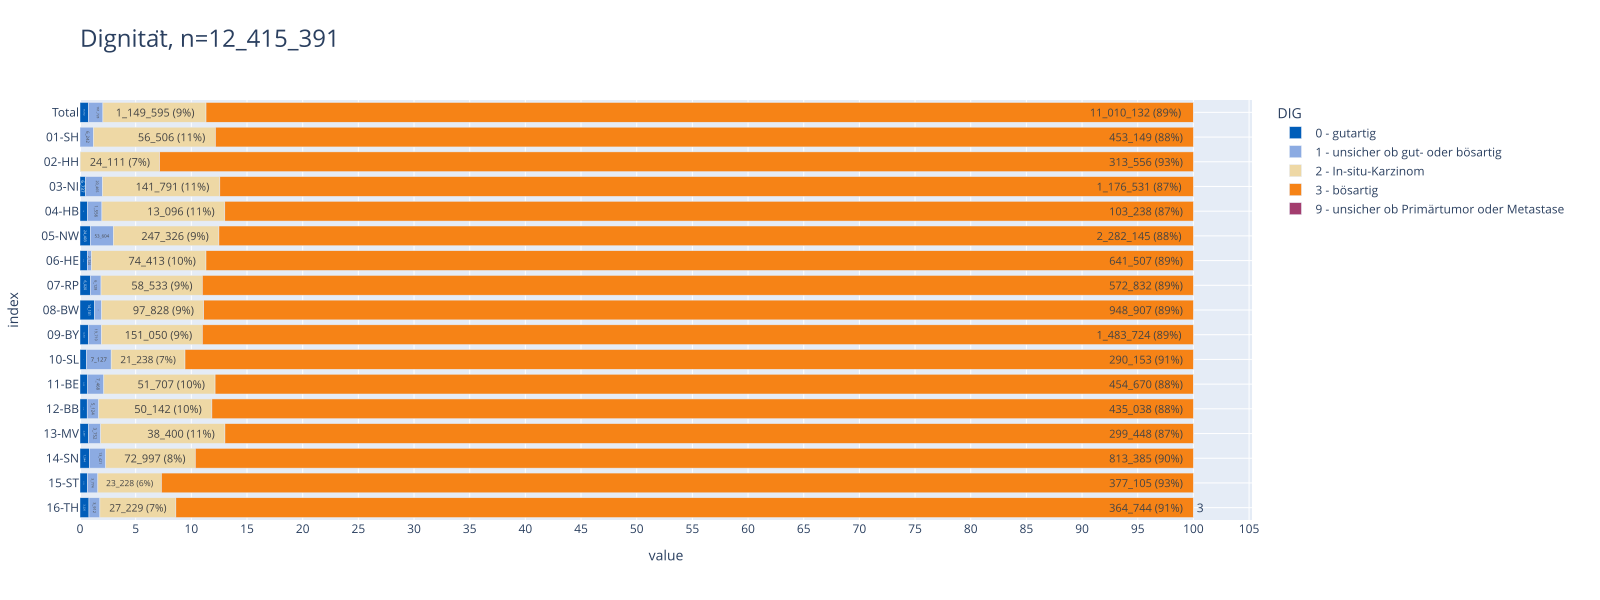

In [21]:
_filters = [
    FILTERS_VALID,
    # FILTERS_DY,
    FILTERS_NO_DCO,
    # FILTERS_C,
    FILTERS_NO_C44,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        --z_dy::text as z_dy,
        --DIG,
        GKZbl_label as bl,
        label as DIG,
        count(*) as cnt,
    from tumor_epi_clin_all tum
    left join dim_dig dig on tum.DIG  = dig.code
    where {_filter}
    group by all
    """
).to_df()
# _df

# _ = pls.plot_facet_stacked_bars(
#     _df,
#     subplot_size=400,
#     relative=True,
#     annotations=True,
#     sort_values_facet=True,
# )

_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    # height=700,
    show_pct_bar=True,
    title="Dignität",
)

<br>

### <a id='toc1_6_2_'></a>[Grading](#toc0_)

> [!NOTE]
> 💡 **ZfKD**: Es zeigen sich unterschiedlich hohe Anteile (0-20%) mit Verwendung des 3-stufigen Gradings (low-intermediate-high) je nach Bundesland

<!-- START_TOKEN -->

n = 17_758_787                                  (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]:      n = 17_038_328  (95.9%) ░░████████████████████████████
└ [DJ ab 2010]:                  n = 11_293_487  (63.6%) ░░░░░░░░░░░███████████████████
└ [keine DCO]:                   n = 10_637_156  (59.9%) ░░░░░░░░░░░░░█████████████████
└ [nur gradingrelevante Tumore]:  n = 3_693_956  (20.8%) ░░░░░░░░░░░░░░░░░░░░░░░░██████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy >= 2010
and not z_is_dco
and 
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 33
            or right(z_icd10_3d, 2)::int8 between 50 and 57
            or right(z_icd10_3d, 2)::int8 between 63 and 68
            or right(z_icd10_3d, 2)::int8 = 60
        )
        and left(Morphologie_Code,4)::int between 8010 and 8576
    )
```

</details>

<!-- ALT_TEXT:Grading-->

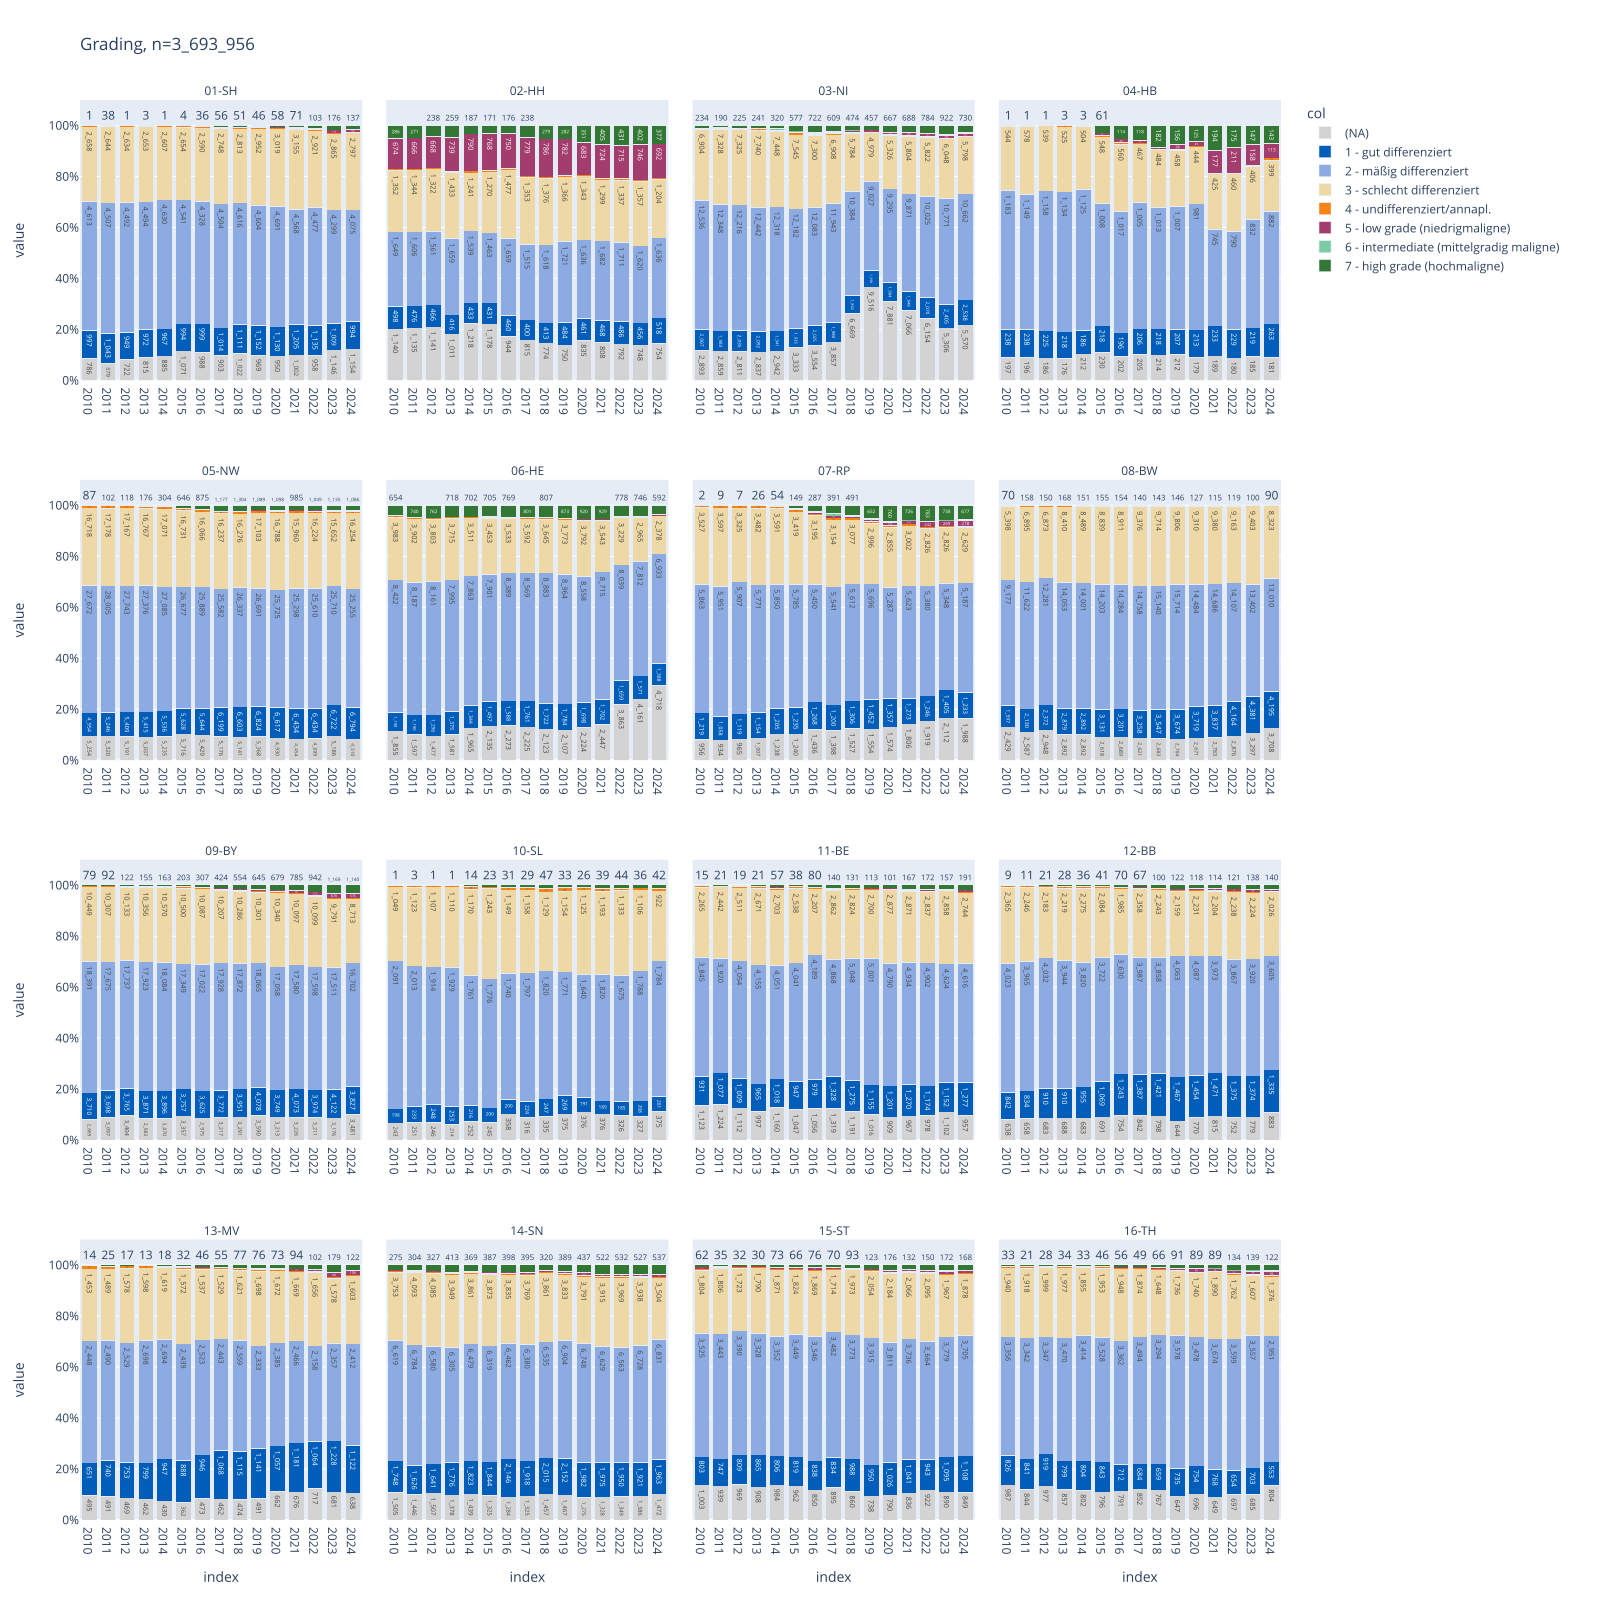

In [22]:
_filters = [
    FILTERS_VALID,
    # FILTERS_DY_MAX,
    # FILTERS_DY,
    FILTERS_DY_FROM_2010,
    # FILTERS_C,
    # FILTERS_NO_C44,
    FILTERS_NO_DCO,
    FILTERS_GRAD,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        z_dy::text as z_dy,
        GKZbl_label as bl,
        label as Grading,
        count(*) as cnt,
    from tumor_epi_clin_all tum
    left join dim_grading_epi gr on tum.GRAD  = gr.code
    where {_filter}
    group by all
    """
).to_df()
# display(_df)

# _=pls.plot_stacked_bars(
#     _df[["bl", "Grading", "cnt"]],
#     orientation="h",
#     normalize=False,
#     relative=True,
#     dropna=False,
#     sort_values_index=False,
#     show_total=True,
#     # height=700,
#     show_pct_bar=True,
# )

_ = pls.plot_facet_stacked_bars(
    _df[["z_dy", "Grading", "bl", "cnt"]],
    relative=True,
    subplot_size=400,
    sort_values_facet=True,
    # sort_values_index=True,
    annotations=True,
    # color_palette=const.PALETTE_RKI2,
    title="Grading",
)

<br>

### <a id='toc1_6_3_'></a>[Altersgruppen Kinder und Heranwachsende](#toc0_)

> [!NOTE]
> 💡 **ZfKD**: Die Abbildung zeigt deutlich, dass einige Register aktuell (fast) keine Fälle bei Kindern mehr erfassen, andere dagegen wahrscheinlich noch relativ vollständig

<!-- START_TOKEN -->

n = 17_758_787                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 17_038_328  (95.9%) ░░████████████████████████████
└ [DJ 2019-2025]:            n = 4_667_333  (26.3%) ░░░░░░░░░░░░░░░░░░░░░░░███████
└ [keine DCO]:               n = 4_446_303  (25.0%) ░░░░░░░░░░░░░░░░░░░░░░░███████
└ [keine C44,D04]:           n = 3_569_966  (20.1%) ░░░░░░░░░░░░░░░░░░░░░░░░██████
└ [Alter <= 20]:                n = 13_955   (0.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy between 2019 and 2025
and not z_is_dco
and z_icd10_3d not in ('C44','D04')
and z_age<=20
```

</details>

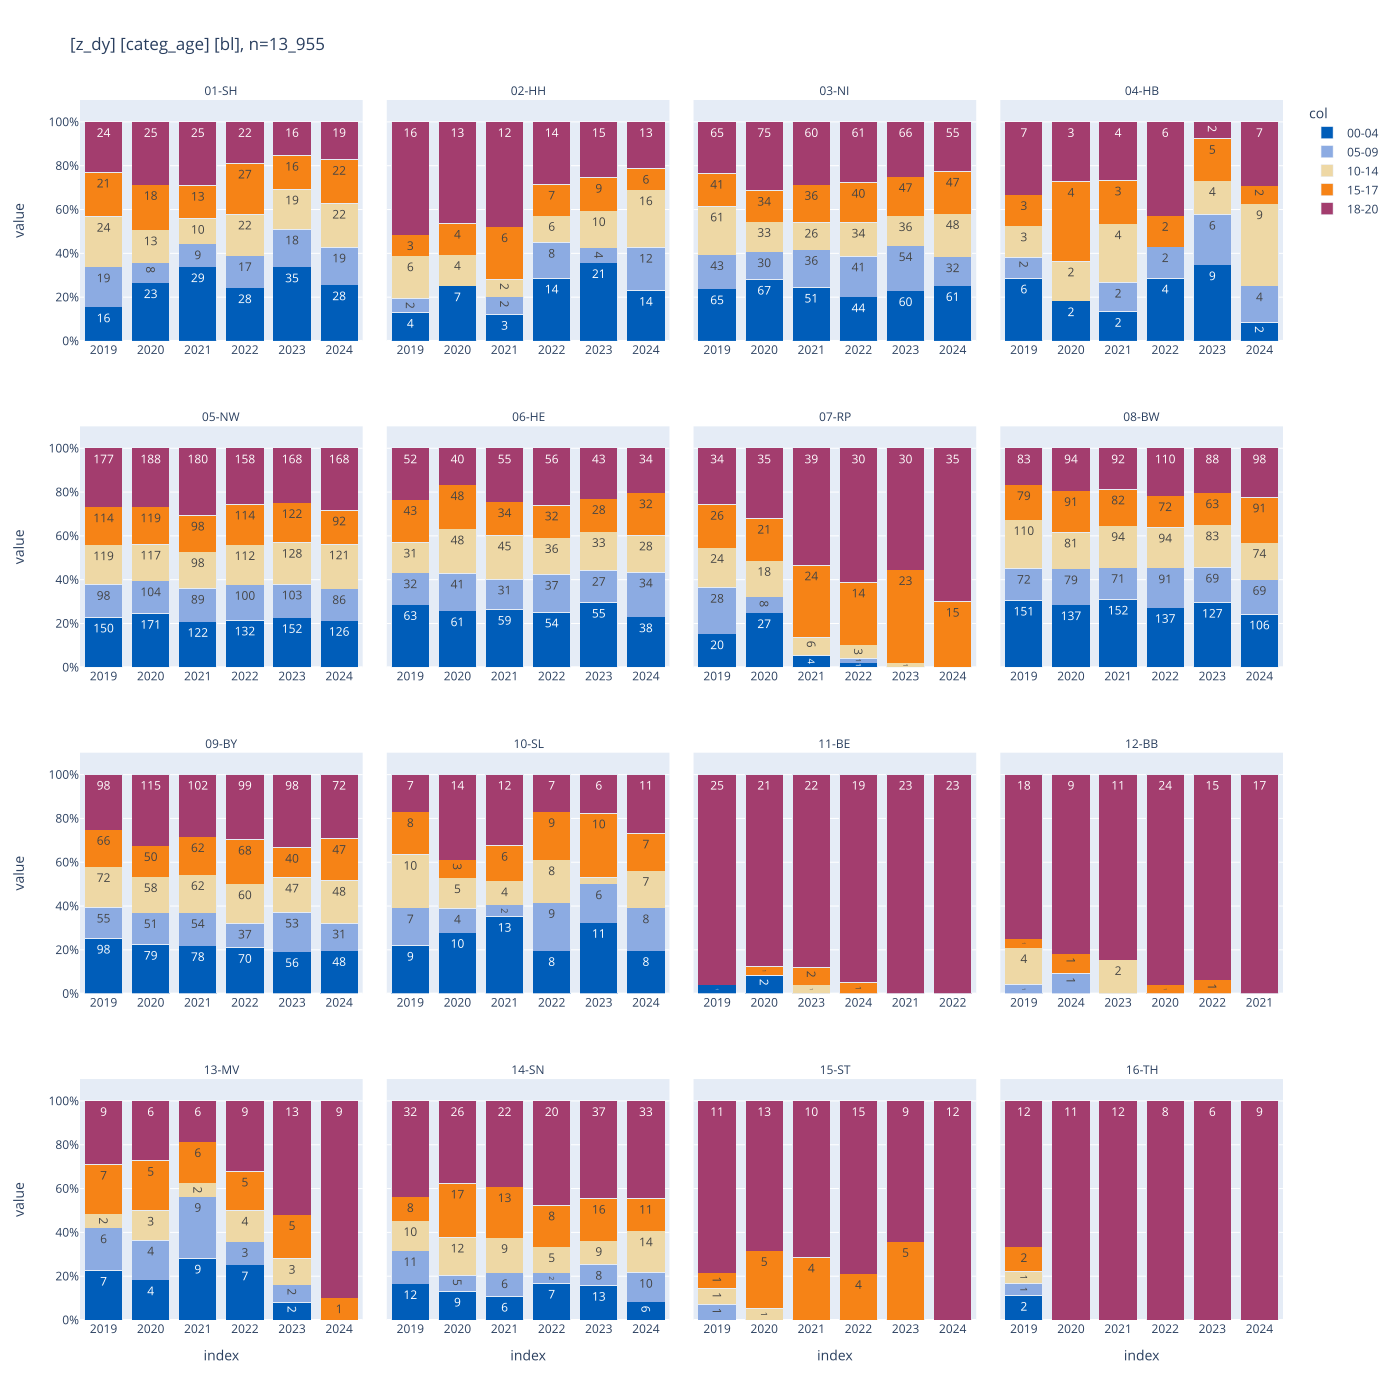

In [23]:
# todo facet bars

_filters = [
    FILTERS_VALID,
    FILTERS_DY_RANGE,
    FILTERS_NO_DCO,
    FILTERS_NO_C44,
    ("z_age<=20", "Alter <= 20"),
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        --z_ag05,
        --z_age,
        z_dy::text as z_dy,
        case
            when z_age::int between 0 and 4 then '00-04'
            when z_age::int between 5 and 9 then '05-09'
            when z_age::int between 10 and 14 then '10-14'
            when z_age::int between 15 and 17 then '15-17'
            when z_age::int between 18 and 20 then '18-20'
        else 'U' end as categ_age,
        GKZbl_label as bl,
        count(*) as cnt,
    from tumor_epi_clin_all tum
    where {_filter}
    group by all
    """
).to_df()
# display(_df)

_df
_=pls.plot_facet_stacked_bars(
    _df,
    relative=True,
    subplot_size=350,
    sort_values_facet=True,
    annotations=True,
    # color_palette=const.PALETTE_RKI2,
)

<br>

### <a id='toc1_6_4_'></a>[UICC](#toc0_)
- die Variable `UICC` wird vom ZfKD gebildet

> [!NOTE]
> 💡 **ZfKD**: Bei TNM-relevanten Tumoren sind TNM-Angaben je nach BL in 42%-76% ausreichend für die Bildung des UICC-Stadiums (MX bzw. unbekannt wird als M0 gewertet) Diese Anteile aben sich in einigen Registern in den letzten 10 Jahren erhöht, in wenigen verringert

<!-- START_TOKEN -->

n = 17_758_787                               (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]:   n = 17_038_328  (95.9%) ░░████████████████████████████
└ [keine C44,D04]:            n = 13_852_611  (78.0%) ░░░░░░░███████████████████████
└ [keine DCO]:                n = 12_415_391  (69.9%) ░░░░░░░░░░████████████████████
└ [nur tnm-relevante Tumore]:  n = 8_940_895  (50.3%) ░░░░░░░░░░░░░░░███████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_icd10_3d not in ('C44','D04')
and not z_is_dco
and 
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 43
            or right(z_icd10_3d, 2)::int8 between 45 and 69
            or right(z_icd10_3d, 2)::int8 between 73 and 74
        )
        and left(Morphologie_Code,4)::int between 8010 and 8790
        and z_icd10_3d not in ('C26', 'C39', 'C55')
        and z_icd10 not in ('C14.0', 'C57.9', 'C63.9')
    )
```

</details>

<!-- ALT_TEXT:UICC-->

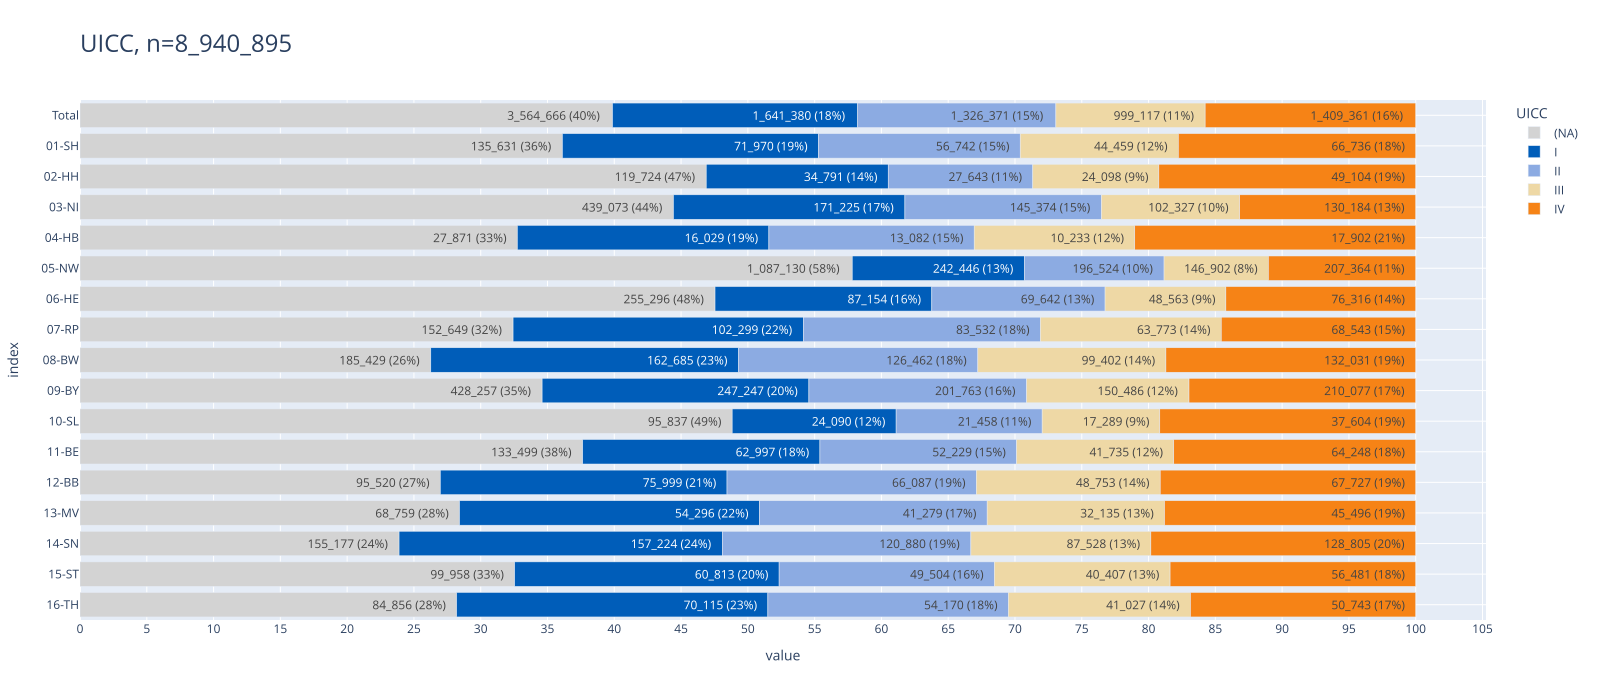

In [24]:
_filters = [
    FILTERS_VALID,
    # FILTERS_DY_MAX,
    # FILTERS_C,
    FILTERS_NO_C44,
    FILTERS_NO_DCO,
    FILTERS_TNM,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        GKZbl_label as bl,
        UICC,
    from tumor_epi_clin_all tum
    where {_filter}
    """
).to_df()
# display(_df)

_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=700,
    show_pct_bar=True,
    title="UICC",
)


<br>

### <a id='toc1_6_5_'></a>[TNM-Auflage](#toc0_)
- nicht übermittelte Auflagen werden im ZfKD geschätzt und imputiert anhand des DJ, daher keine missings im Datensatz

> 💡 **ZfKD**: Auflage 7 wird nur noch von 03-NI in nennenswertem Umfang übermittelt

<!-- START_TOKEN -->

n = 17_758_787                               (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]:   n = 17_038_328  (95.9%) ░░████████████████████████████
└ [DJ ab 2010]:               n = 11_293_487  (63.6%) ░░░░░░░░░░░███████████████████
└ [keine DCO]:                n = 10_637_156  (59.9%) ░░░░░░░░░░░░░█████████████████
└ [nur tnm-relevante Tumore]:  n = 5_862_472  (33.0%) ░░░░░░░░░░░░░░░░░░░░░█████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and DJ >= 2010
and not z_is_dco
and 
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 43
            or right(z_icd10_3d, 2)::int8 between 45 and 69
            or right(z_icd10_3d, 2)::int8 between 73 and 74
        )
        and left(Morphologie_Code,4)::int between 8010 and 8790
        and z_icd10_3d not in ('C26', 'C39', 'C55')
        and z_icd10 not in ('C14.0', 'C57.9', 'C63.9')
    )
```

</details>

<!-- ALT_TEXT:TNM-Auflage-->

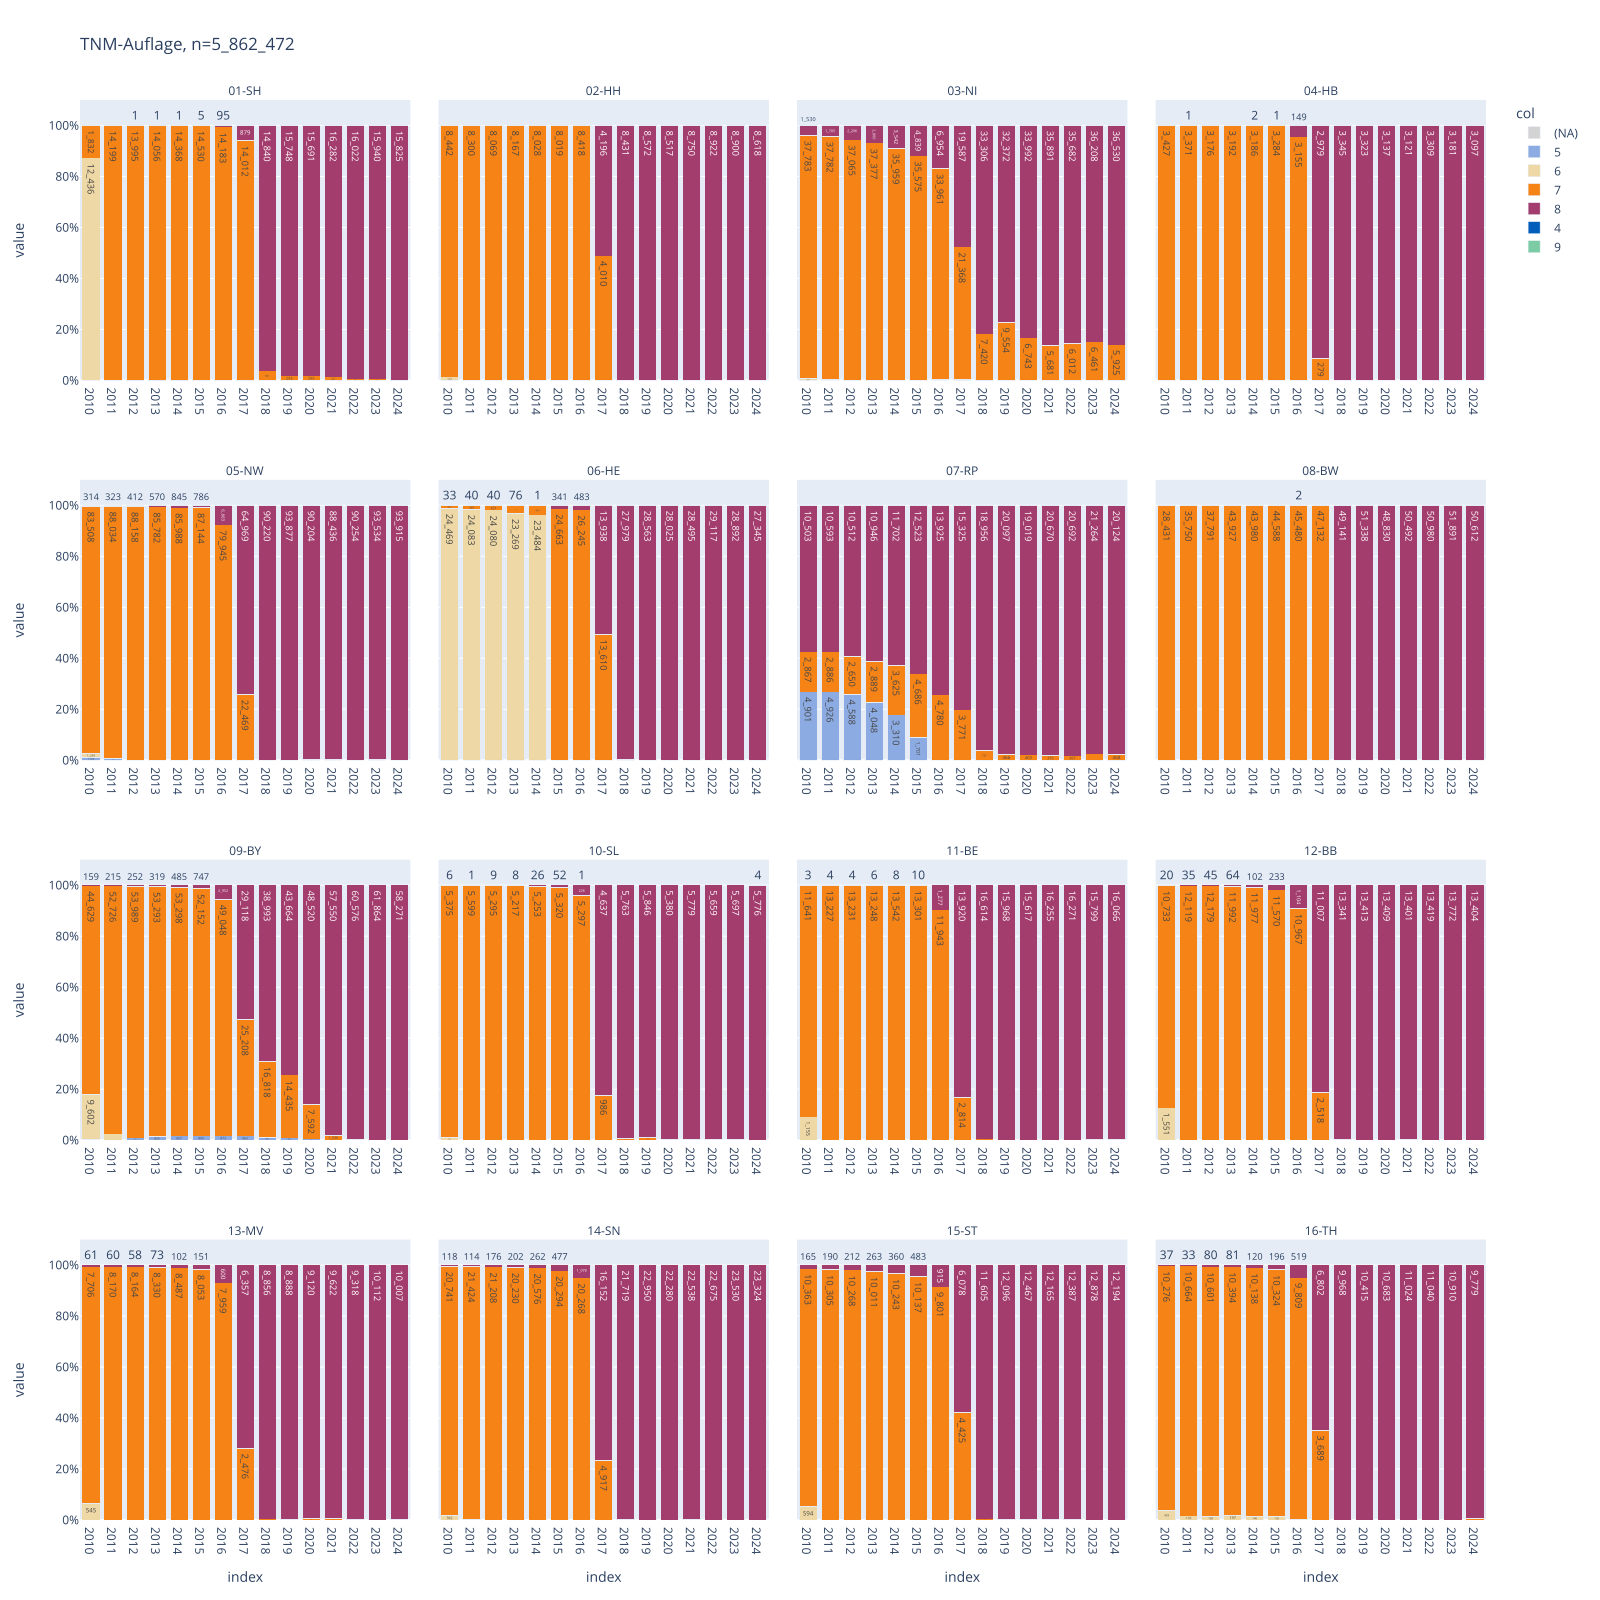

In [25]:
_filters = [
    FILTERS_VALID,
    # FILTERS_DY_MAX,
    # FILTERS_DY_RANGE,
    ("DJ >= 2010", "DJ ab 2010"),
    # FILTERS_C,
    # FILTERS_NO_C44,
    FILTERS_NO_DCO,
    FILTERS_TNM,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        z_dy::text as z_dy,
        TNM_Auflage_p,
        GKZbl_label as bl,
    from tumor_epi_clin_all tum
    where {_filter}
    """
).to_df()
# display(_df)

_=pls.plot_facet_stacked_bars(
    _df,
    relative=True,
    subplot_size=400,
    sort_values_facet=True,
    # sort_values_index=True,
    annotations=True,
    # color_palette=const.PALETTE_RKI2,
    fill_index=True,
    title="TNM-Auflage",
)

<br>

### <a id='toc1_6_6_'></a>[Tod](#toc0_)

#### <a id='toc1_6_6_1_'></a>[Anteil Verstorbene](#toc0_)
- gezählt sind **Personen**
- Metrik: Anteil Verstorbene

> [!NOTE]
> 💡 **ZfKD**: 
> - auffallend (aber bekannt) ist hier der offensichtlich noch zu niedrige Anteil in TH
> - auch in einem Bezirk in Bayern (Oberbayern) ist der Mortalitätsabgleich zumindest für 2024 noch unvollständig

In [28]:
_filters = [
    FILTERS_VALID,
    # FILTERS_DY_MAX,
    FILTERS_DY,
    # FILTERS_C,
    FILTERS_NO_C44,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    distinct_metric="GLOBALPATID",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    with t1 as (
    select
        z_pat_id,
        any_value(z_dy::text) as z_dy,
        any_value(GKZbl_label) as bl,
        any_value(Verstorben) as Verstorben,
    from tumor_epi_clin_all
    where {_filter}
    group by z_pat_id
    ),
    t2 as (
        select
            z_dy::text as z_dy,
            bl,
            count(*) as cnt,
            count(*) filter (where Verstorben = 'J') as cnt_deceased,
            cnt_deceased / cnt as pct_deceased,
        from t1
        group by all
        
        union
        select
            'Total' as z_dy,
            bl,
            count(*) as cnt,
            count(*) filter (where Verstorben = 'J') as cnt_deceased,
            cnt_deceased / cnt as pct_deceased,
        from t1
        group by all
        
        union
        select
            z_dy::text as z_dy,
            'Total' as bl,
            count(*) as cnt,
            count(*) filter (where Verstorben = 'J') as cnt_deceased,
            cnt_deceased / cnt as pct_deceased,
        from t1
        group by all
        
        union
        select
            'Total' as z_dy,
            'Total' as bl,
            count(*) as cnt,
            count(*) filter (where Verstorben = 'J') as cnt_deceased,
            cnt_deceased / cnt as pct_deceased,
        from t1
        group by all
    )
    select * from t2
    """
).to_df()
# display(_df)

tbl.pivot_df(
    _df[["z_dy", "bl", "pct_deceased"]],
    total_axis="",
    pct_axis="",
    show_as_pct=True,
    precision=1,
    font_size_th=12,
    font_size_td=11,
    swap=True,
    image_scale="60%",
)

<!-- START_TOKEN -->

count: distinct GLOBALPATID
---
n = 15_146_405                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 14_648_040  (96.7%) ░█████████████████████████████
└ [DJ 2020-2024]:            n = 3_611_701  (23.8%) ░░░░░░░░░░░░░░░░░░░░░░░███████
└ [keine C44,D04]:           n = 2_999_925  (19.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░█████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy between 2020 and 2024
and z_icd10_3d not in ('C44','D04')
```

</details>

<!-- SCALE-60% -->

z_dy,2020,2021,2022,2023,2024,Total
bl,,,,,,
01-SH,43.3%,39.7%,36.7%,31.7%,24.4%,35.3%
02-HH,38.6%,35.0%,30.7%,24.8%,18.4%,29.5%
03-NI,44.7%,41.3%,37.6%,31.0%,20.7%,35.0%
04-HB,46.3%,40.2%,35.7%,30.2%,20.2%,34.6%
05-NW,41.7%,38.3%,34.5%,27.9%,16.6%,31.7%
06-HE,44.0%,39.3%,35.7%,29.5%,20.7%,33.9%
07-RP,39.7%,35.4%,31.4%,24.9%,16.4%,29.7%
08-BW,37.9%,33.1%,28.1%,22.2%,14.8%,27.1%
09-BY,37.0%,33.3%,29.5%,22.2%,12.3%,27.0%


#### <a id='toc1_6_6_2_'></a>[Verteilung Todesursachen nach ICDT10](#toc0_)
- gezählt sind **Personen**
- `icdt10_1d` gibt die erste Stelle der Todesursache (TU) an

> [!NOTE]
> 💡 **ZfKD**
> - mit steigender Beobachtungszeit steigt der Anteil von anderen Todesursachen natürlicherweise an
> - auffallend ist allerdings der in 2024 geringe (und zuletzt stark gesunkene) Anteil krebsbedingter Todesfälle in `09-BY`
> - in den westdeutschen Bundesländern sind zuletzt ganz überwiegend TU angegeben, aus den ostdeutschen Registern liegen aktuell keine Angaben vor.

<!-- START_TOKEN -->

count: distinct GLOBALPATID
---
n = 15_146_405                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 14_648_040  (96.7%) ░█████████████████████████████
└ [nur Verstorbene]:         n = 7_576_084  (50.0%) ░░░░░░░░░░░░░░░███████████████
└ [SJ ab 2010]:              n = 5_116_941  (33.8%) ░░░░░░░░░░░░░░░░░░░░██████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and Verstorben = 'J'
and year(SDIMP) >= 2010
```

</details>

<!-- ALT_TEXT:Todesursachen nach Sterbejahr-->

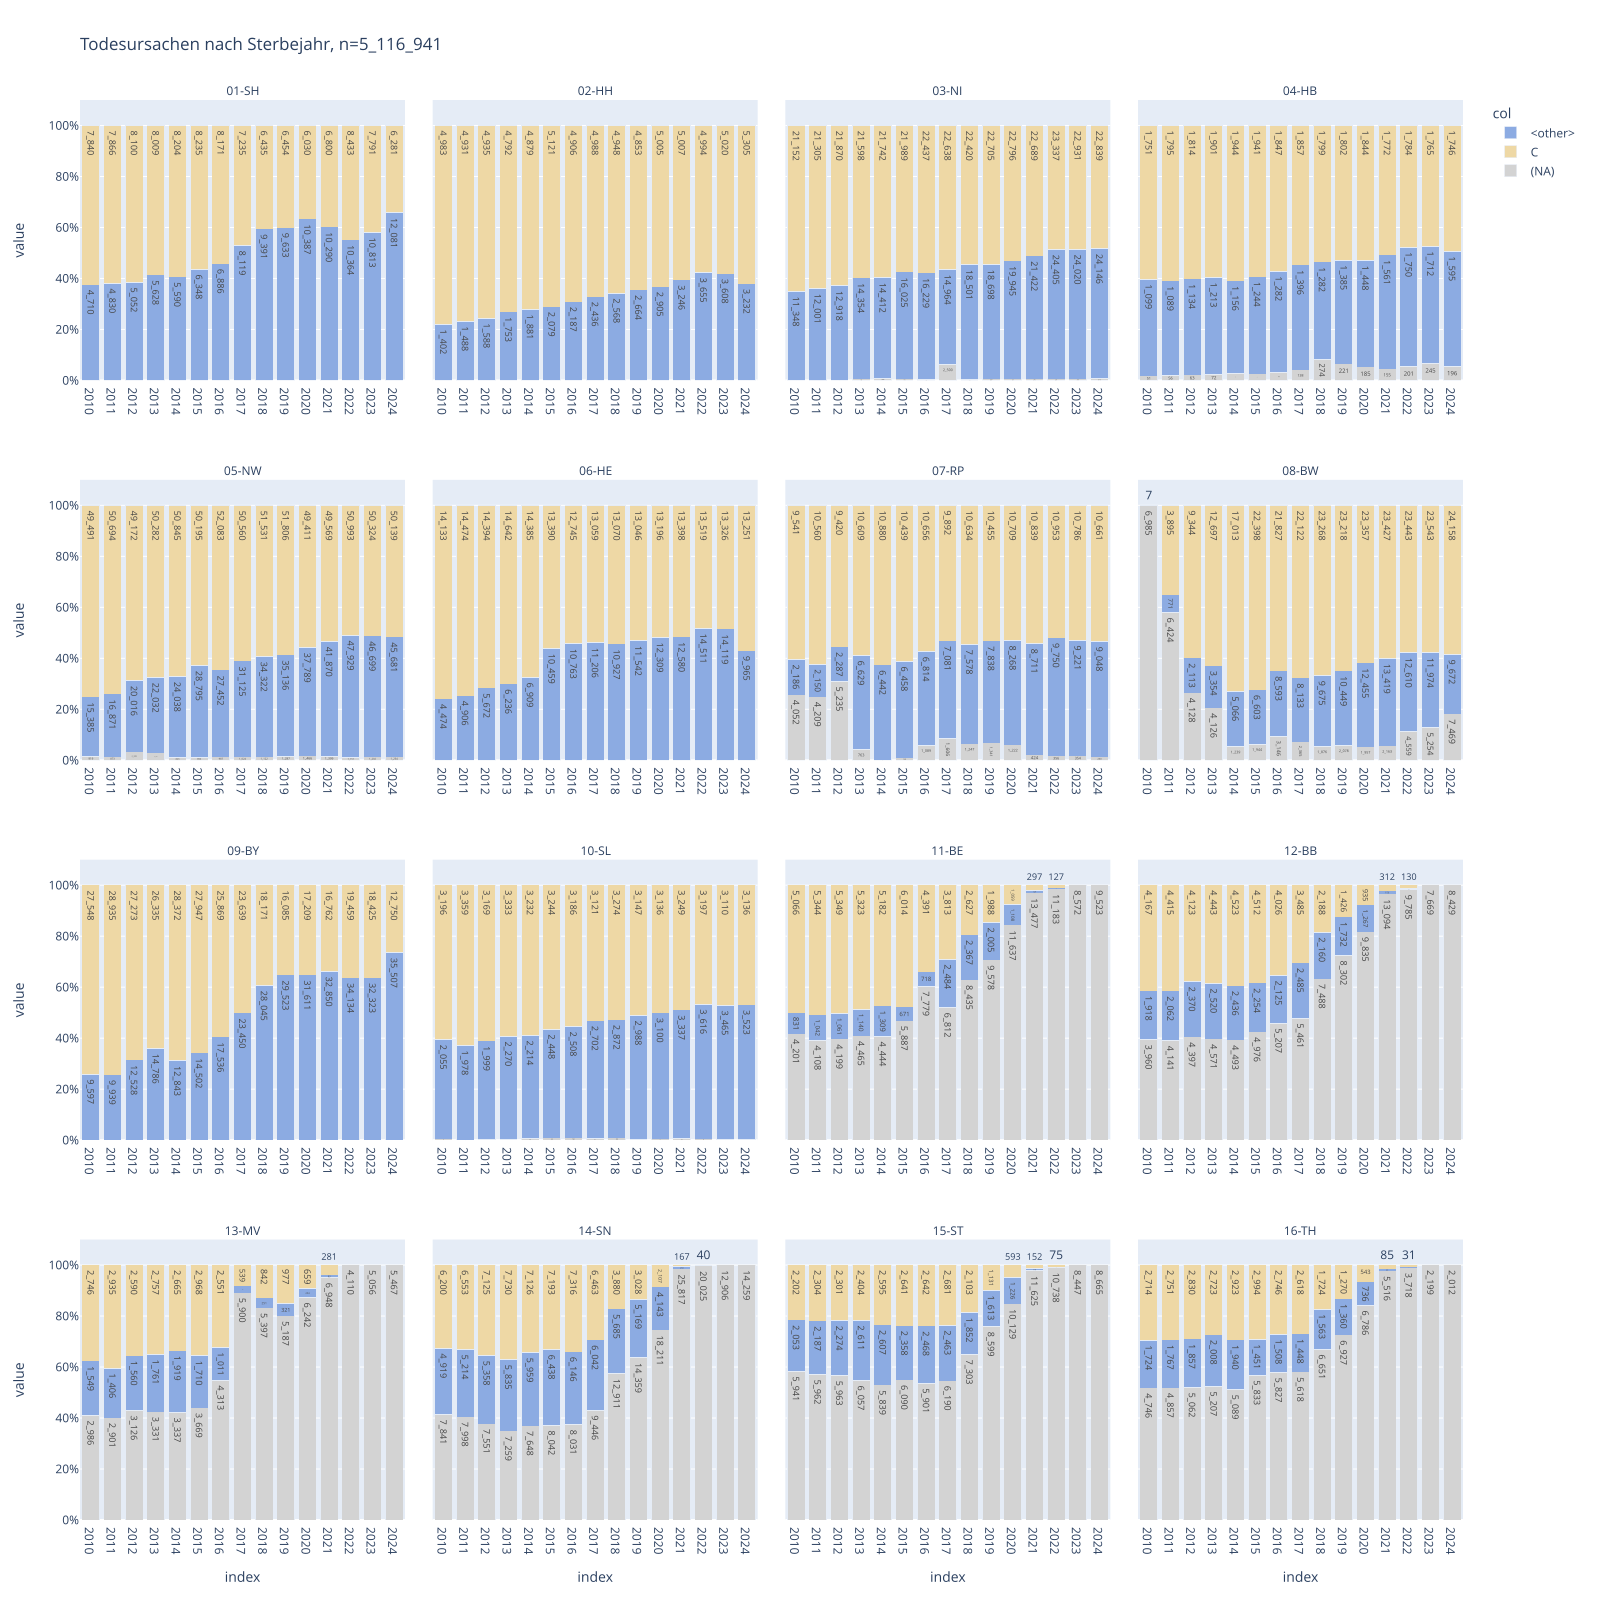

In [27]:
_filters = [
    FILTERS_VALID,
    ("Verstorben = 'J'", "nur Verstorbene"),
    ("year(SDIMP) >= 2010", "SJ ab 2010"),
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    distinct_metric="GLOBALPATID",
    first_n_filter_apply_to_rows=0,
)

_df = (con.sql(f"""--sql
    with t1 as (
        select
            year(SDIMP)::text as SJ,
            ICDT10,
            GKZbl_label as bl,
            case
                when ifnull(ICDT10,'') = '' then null
                when upper(left(ICDT10,1)) = 'C' then 'C'
            else '<other>' end as icdt10_1d,
            GLOBALPATID,
        from tumor_epi_clin_all
        where {_filter}
    ),
    t2 as (
        select 
            any_value(SJ) as SJ,
            any_value(icdt10_1d) as icdt10_1d,
            any_value(bl) as bl,
        from t1
        group by GLOBALPATID
    ),
    t3 as (
        select
            *,
            count(*) as cnt
        from t2
        group by all
    )
    select * from t3
    """)
    # .filter("SJ::int >= 2010 and GKZbl::int <= 16")
    .order("bl")
    .to_df()
)
# display(_df)

_ = pls.plot_facet_stacked_bars(
    _df,
    # df_tu[["SJ","icdt10_1d","GKZbl"]],
    # df_tu[["DJ","ICDT10","EKRNR"]],
    # top_n_color=5,
    subplot_size=400,
    sort_values_facet=True,
    # sort_values_index=True,
    relative=True,
    annotations=True,
    color_palette=const.PALETTE_RKI2,
    title="Todesursachen nach Sterbejahr"
)